**Import Liberies**

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#import the raw data(using 'sep="\t"' because all datas are marged)
df = pd.read_csv(r"customer personality.csv",sep="\t")

In [ ]:
#check the Shape of the data
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

**Data Cleaning**

In [5]:
#Check Missing Values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [6]:
#Handle Missing Values
df = df.dropna(subset=['Income'])

In [ ]:
#Check Duplicate Records present or not
df.duplicated().sum()

0

In [ ]:
#Convert Data Types of date
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y')

In [9]:
#Rename Columns
df.rename(columns={'MntWines':'Wine',
                   'MntMeatProducts':'Meat',
                   'MntFishProducts':'Fish',
                   'MntSweetProducts':'Sweet',
                   'MntGoldProds':'Gold',
                   'MntFruits':'Fruit'
                   },inplace=True)

<Axes: ylabel='Income'>

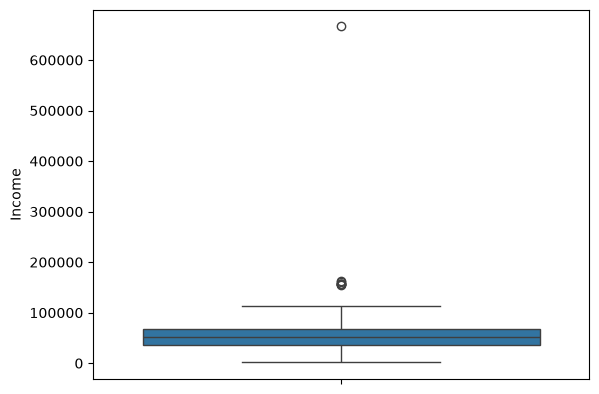

In [10]:
#Check Outliers For Income
sns.boxplot(df['Income'])

In [ ]:
#Optional removal outlier
Q1= df['Income'].quantile(.25)
Q3= df['Income'].quantile(.75)

IQR=Q3-Q1

Upper_limit=Q3+(IQR*1.5)
Lower_limit=Q1-(IQR*1.5)

clean_df = df[(df['Income'] >= Lower_limit) & (df['Income'] <= Upper_limit)]

-14525.5 118350.5


<Axes: ylabel='Income'>

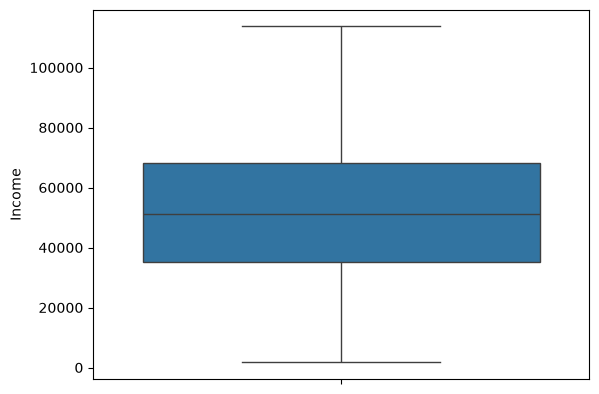

In [ ]:
# showing outlier remove or not
sns.boxplot(clean_df['Income'])

**Feature Engineering**

In [11]:
#Create Customer Age
df['Age'] = 2026 - df['Year_Birth']

In [12]:
#Total Children
df['Children'] = df['Kidhome'] + df['Teenhome']

In [13]:
#Total Spending
df['Total_Spending'] = (
      df['Wine']
    + df['Fruit']
    + df['Meat']
    + df['Fish']
    + df['Sweet']
    + df['Gold'])

In [14]:
#Total Purchases
df['Total_Purchases'] = (
      df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases'])

In [15]:
#Family Size
df['Family_Size'] = (
    df['Marital_Status'].replace({
        'Single':1,
        'Together':2,
        'Married':2,
        'Divorced':1,
        'Widow':1,
        'Alone':1,
        'YOLO':1,
        'Absurd':2})+ df['Children'])

In [16]:
#Customer Since
df['Customer_Years'] = 2026 - df['Dt_Customer'].dt.year

**Exploratory Data Analysis (EDA)**

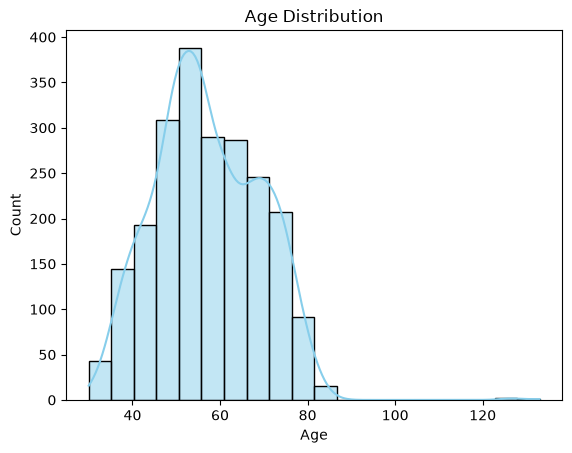

In [17]:
#Age Distribution
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [18]:
#Statistics
df['Age'].describe()

count    2216.000000
mean       57.179603
std        11.985554
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

In [19]:
#Skewness
print("Skewness :", df['Age'].skew())

Skewness : 0.35366147002882264


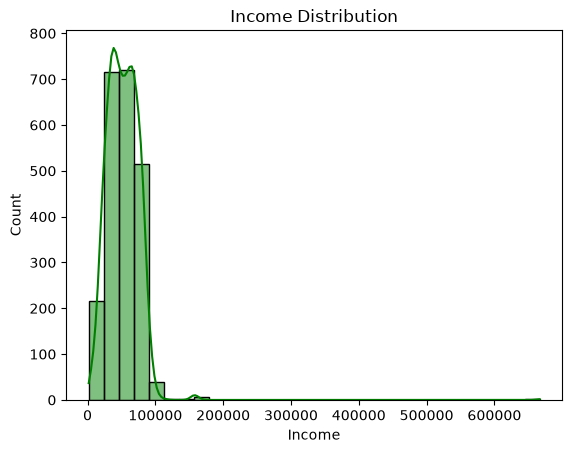

In [20]:
#Income Distribution
sns.histplot(df['Income'],
             bins=30,
             kde=True,
             color='green')

plt.title("Income Distribution")

plt.show()

In [21]:
#Statistics
df['Income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

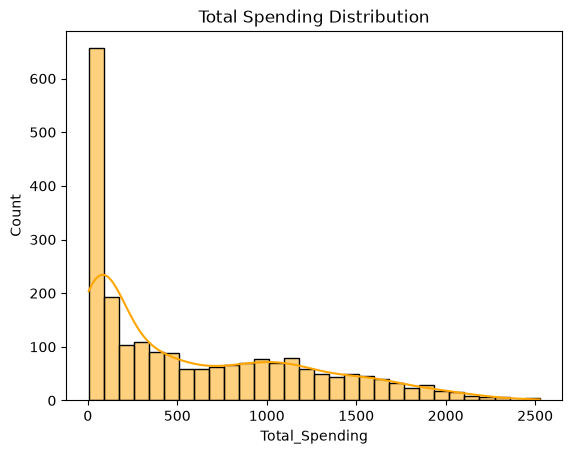

In [22]:
#Total Spending Distribution
sns.histplot(df['Total_Spending'],
             bins=30,
             kde=True,
             color='orange')

plt.title("Total Spending Distribution")

plt.show()

In [23]:
#Statistics
df['Total_Spending'].describe()

count    2216.000000
mean      607.075361
std       602.900476
min         5.000000
25%        69.000000
50%       396.500000
75%      1048.000000
max      2525.000000
Name: Total_Spending, dtype: float64

<Axes: xlabel='Total_Spending'>

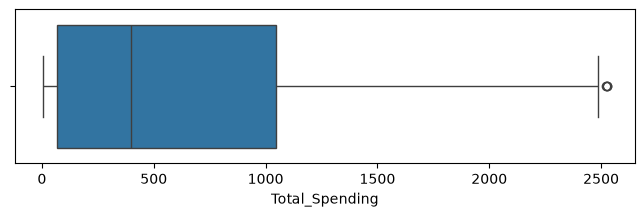

In [24]:
#Check outlier
plt.figure(figsize=(8,2))
sns.boxplot(x=df['Total_Spending'])

**Categorical Analysis**

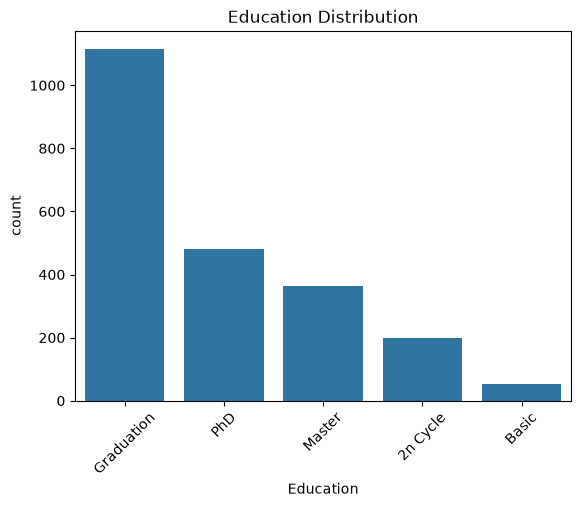

In [25]:
#Education Distribution
order = df['Education'].value_counts().index

sns.countplot(data=df,
              x='Education',
              order=order)

plt.xticks(rotation=45)

plt.title("Education Distribution")

plt.show()

In [26]:
#count Table
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [27]:
#Percentage
round(df['Education'].value_counts(normalize=True)*100,2)

Education
Graduation    50.36
PhD           21.71
Master        16.47
2n Cycle       9.03
Basic          2.44
Name: proportion, dtype: float64

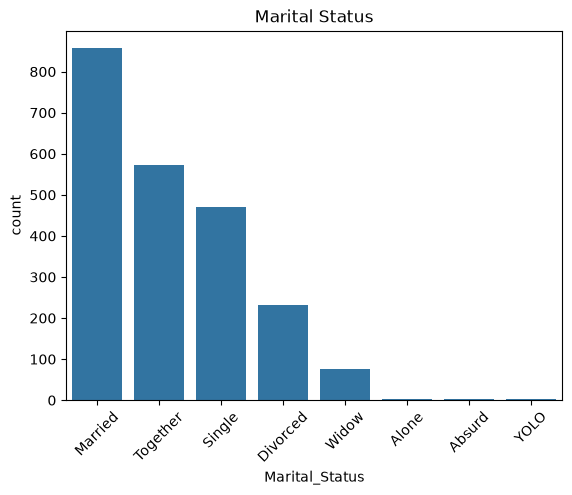

In [28]:
#Marital Status
order = df['Marital_Status'].value_counts().index

sns.countplot(data=df,
              x='Marital_Status',
              order=order)

plt.xticks(rotation=45)

plt.title("Marital Status")

plt.show()

In [29]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [30]:
round(df['Marital_Status'].value_counts(normalize=True)*100,2)

Marital_Status
Married     38.67
Together    25.86
Single      21.25
Divorced    10.47
Widow        3.43
Alone        0.14
Absurd       0.09
YOLO         0.09
Name: proportion, dtype: float64

**Bivariate Analysis**

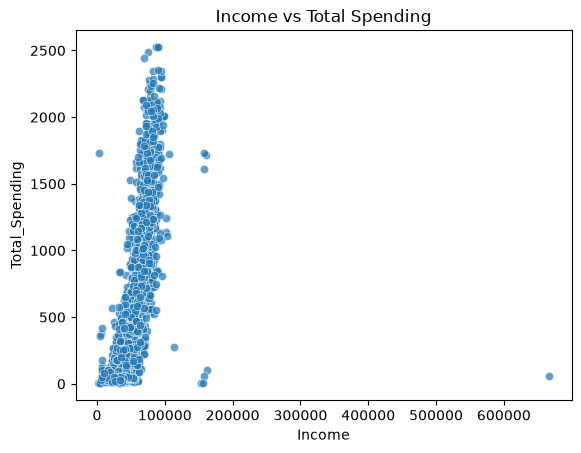

In [31]:
#Income vs Spending
sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending',
    alpha=0.7)
plt.title("Income vs Total Spending")

plt.show()

In [32]:
#Correlation
df[['Income','Total_Spending']].corr()

,Income,Total_Spending
Income,1.000000,0.667576
Total_Spending,0.667576,1.000000


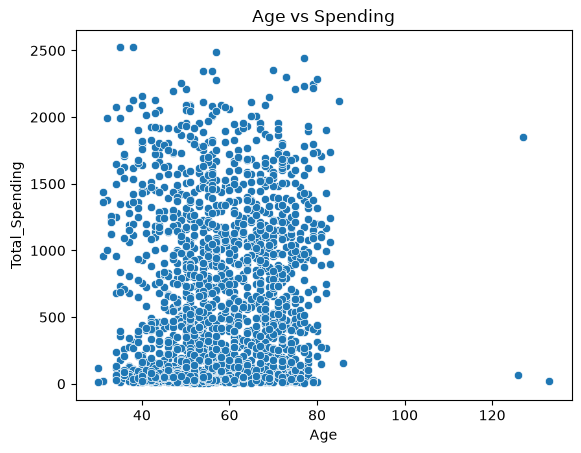

In [33]:
#Age vs Spending
sns.scatterplot(
    data=df,
    x='Age',
    y='Total_Spending')
plt.title("Age vs Spending")

plt.show()

In [34]:
#Correlation
df[['Age','Total_Spending']].corr()

,Age,Total_Spending
Age,1.000000,0.113487
Total_Spending,0.113487,1.000000


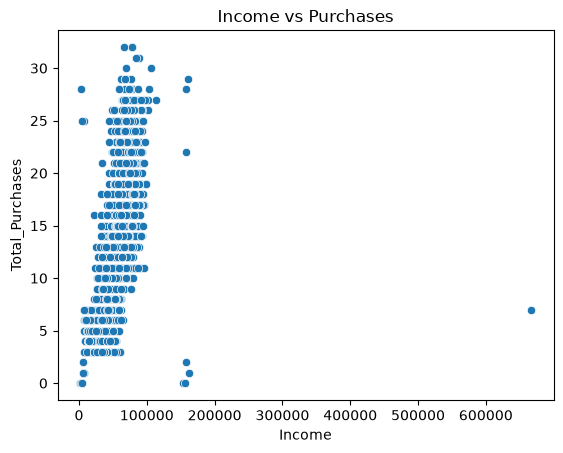

In [35]:
#Income vs Purchases
sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Purchases')
plt.title("Income vs Purchases")

plt.show()

In [36]:
#Correlation
df[['Income','Total_Purchases']].corr()

,Income,Total_Purchases
Income,1.000000,0.625755
Total_Purchases,0.625755,1.000000


**Correlation Heatmap**

In [37]:
numeric = df.select_dtypes(include=np.number)
#Correlation Matrix
corr = numeric.corr()

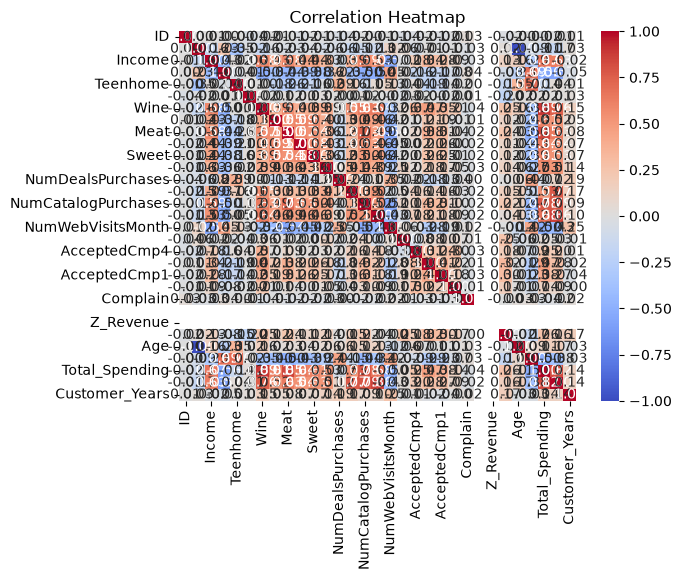

In [38]:
#Heatmap
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Heatmap")

plt.show()

**Campaign Acceptance Analysis**

In [39]:
#First calculate campaign acceptance rates.
campaign = pd.DataFrame({
'Campaign':['Cmp1','Cmp2','Cmp3','Cmp4','Cmp5','Last Campaign'],
'Accepted':[

df['AcceptedCmp1'].sum(),
df['AcceptedCmp2'].sum(),
df['AcceptedCmp3'].sum(),
df['AcceptedCmp4'].sum(),
df['AcceptedCmp5'].sum(),
df['Response'].sum()]})

campaign

,Campaign,Accepted
0,Cmp1,142
1,Cmp2,30
2,Cmp3,163
3,Cmp4,164
4,Cmp5,162
5,Last Campaign,333


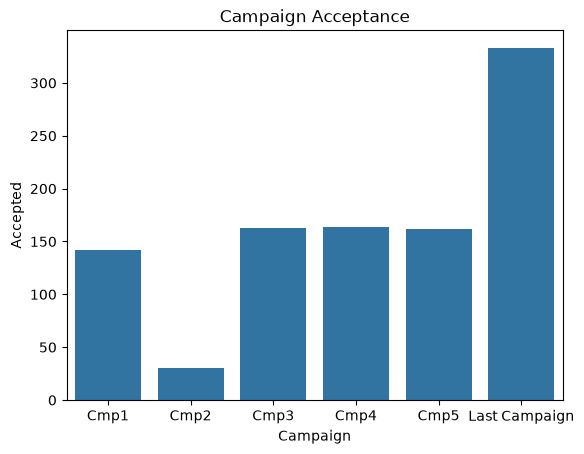

In [40]:
#Visualization
sns.barplot(
    data=campaign,
    x='Campaign',
    y='Accepted')
plt.title("Campaign Acceptance")

plt.show()

In [41]:
#Acceptance Percentage
campaign['Acceptance %'] = round(
campaign['Accepted']/len(df)*100,2)

campaign

,Campaign,Accepted,Acceptance %
0,Cmp1,142,6.41
1,Cmp2,30,1.35
2,Cmp3,163,7.36
3,Cmp4,164,7.40
4,Cmp5,162,7.31
5,Last Campaign,333,15.03


In [42]:
#Product Preference Analysis
products = {
    'Wine': df['Wine'].sum(),
    'Fruit': df['Fruit'].sum(),
    'Meat': df['Meat'].sum(),
    'Fish': df['Fish'].sum(),
    'Sweet': df['Sweet'].sum(),
    'Gold': df['Gold'].sum()}

products

{'Wine': 676083,
 'Fruit': 58405,
 'Meat': 370063,
 'Fish': 83405,
 'Sweet': 59896,
 'Gold': 97427}

In [43]:
#Convert to DataFrame
product_df = pd.DataFrame(
products.items(),
columns=['Product','Sales'])

product_df

,Product,Sales
0,Wine,676083
1,Fruit,58405
2,Meat,370063
3,Fish,83405
4,Sweet,59896
5,Gold,97427


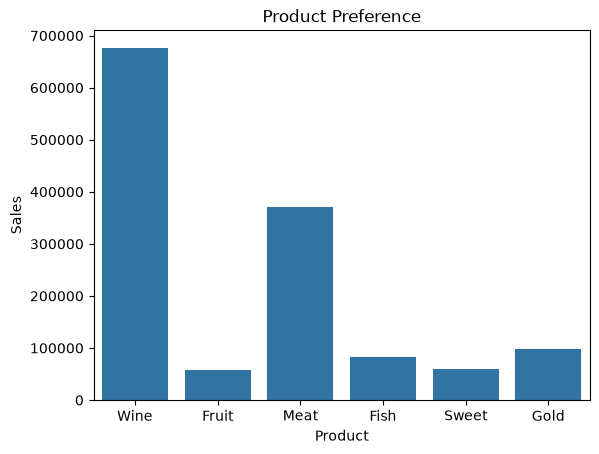

In [44]:
#bar plot
sns.barplot(
data=product_df,
x='Product',
y='Sales')
plt.title("Product Preference")

plt.show()

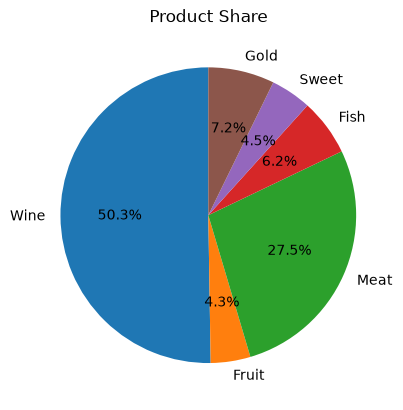

In [45]:
# pie chart
plt.pie(
product_df['Sales'],
labels=product_df['Product'],
autopct='%1.1f%%',
startangle=90)
plt.title("Product Share")

plt.show()

**Data Preparation for Clustering**

In [50]:
#Choose features for clustering.
features = df[['Income',
               'Age',
               'Total_Spending',
               'Total_Purchases',
               'Family_Size']]
#Normalize them.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

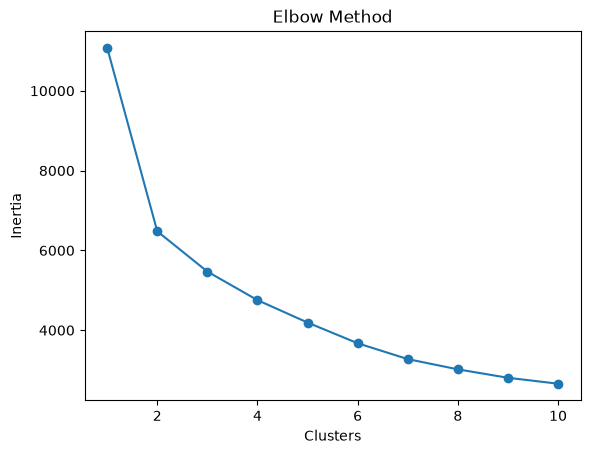

In [51]:
#Find Optimal Number of Clusters : Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia = []

for k in range(1,11):
    model = KMeans(n_clusters=k,
                   random_state=42,
                   n_init=10)

    model.fit(scaled_features)

    inertia.append(model.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

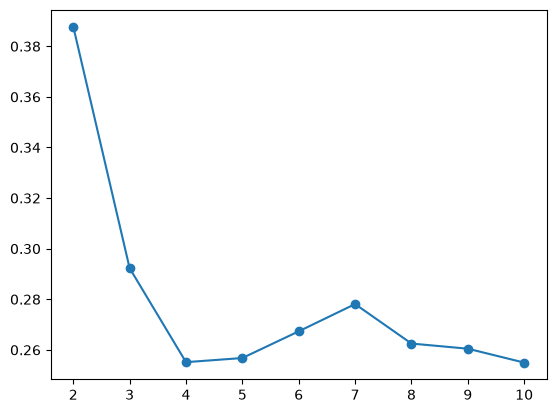

In [ ]:
#Silhouette Score
from sklearn.metrics import silhouette_score

scores=[]

for k in range(2,11):
    model=KMeans(n_clusters=k,
                 random_state=42,
                 n_init=10)

    labels=model.fit_predict(scaled_features)
    scores.append(silhouette_score(scaled_features,labels))

plt.plot(range(2,11),scores,marker='o')

In [53]:
#Build Customer Segments: Suppose the best K is 4.
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10)

df['Cluster'] = kmeans.fit_predict(scaled_features)
#Now every customer belongs to a segment.

**Cluster Analysis**

In [ ]:
# Base summary with numeric averages
cluster_summary = df.groupby('Cluster')[[
    'Income',
    'Age',
    'Total_Spending',
    'Total_Purchases',
    'Family_Size']].mean()

# Add number of customers
cluster_summary['Num_Customers'] = df.groupby('Cluster')['ID'].count()

# Add campaign acceptance (mean of binary flag)
df['Campaign_Acceptance'] = df[[
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response']].max(axis=1)

cluster_summary['Campaign_Acceptance'] = df.groupby('Cluster')['Campaign_Acceptance'].mean()
cluster_summary['Avg_Age'] = df.groupby('Cluster')['Age'].mean()

# Add average income, spending, purchases, age (already included, but for clarity)
cluster_summary['Avg_Income'] = df.groupby('Cluster')['Income'].mean()
cluster_summary['Avg_Spending'] = df.groupby('Cluster')['Total_Spending'].mean()
cluster_summary['Avg_Purchases'] = df.groupby('Cluster')['Total_Purchases'].mean()
cluster_summary['Avg_Age'] = df.groupby('Cluster')['Age'].mean().round(0).astype(int)

# Education distribution (proportions per cluster)
education_dist = df.groupby(['Cluster','Education']).size().unstack(fill_value=0)
education_dist = education_dist.div(education_dist.sum(axis=1), axis=0)

# Marital status distribution (proportions per cluster)
marital_dist = df.groupby(['Cluster','Marital_Status']).size().unstack(fill_value=0)
marital_dist = marital_dist.div(marital_dist.sum(axis=1), axis=0)

# Final outputs
print(cluster_summary)
print("\nEducation Distribution by Cluster:\n", education_dist)
print("\nMarital Status Distribution by Cluster:\n", marital_dist)

               Income        Age  Total_Spending  Total_Purchases Family_Size  \
Cluster                                                                         
0        44950.571930  62.121053      225.238596         8.738596    3.564912   
1        67341.157609  68.826087     1028.048913        18.717391    2.237319   
2        75754.505967  48.577566     1363.599045        19.835322    1.945107   
3        31473.520000  48.822222      115.647407         6.226667    2.466667   

         Num_Customers  Campaign_Acceptance  Avg_Age    Avg_Income  \
Cluster                                                              
0                  570             0.161404       62  44950.571930   
1                  552             0.375000       69  67341.157609   
2                  419             0.472554       49  75754.505967   
3                  675             0.160000       49  31473.520000   

         Avg_Spending  Avg_Purchases  
Cluster                               
0          225

**Cluster Visualization**

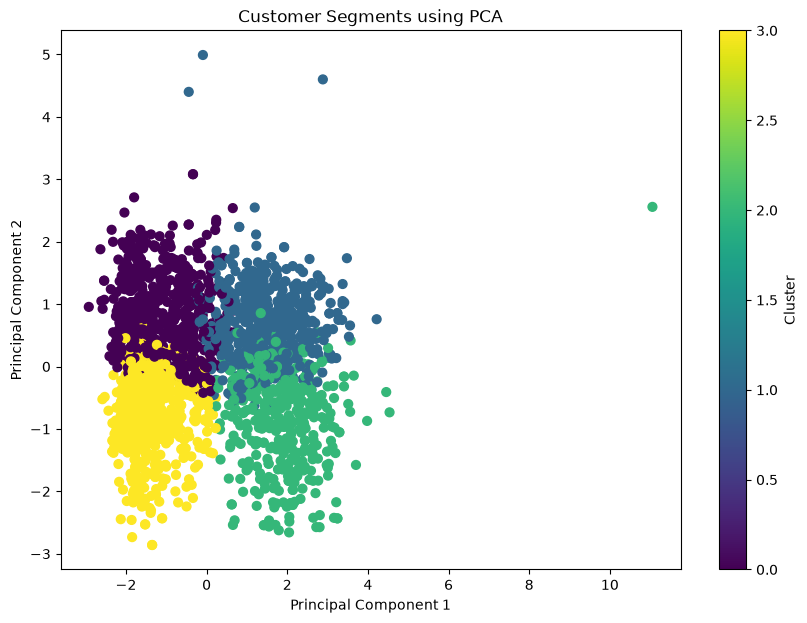

In [75]:
#PCA(2D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

components = pca.fit_transform(scaled_features)
#Sctter plot
plt.figure(figsize=(10,7))
plt.scatter(
    df['PC1'],
    df['PC2'],
    c=df['Cluster'],
    cmap='viridis',
    s=40)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label='Cluster')

plt.show()

In [ ]:
#Cluster Summary
cluster_summary = df.groupby('Cluster').agg({
    'Income':'mean',
    'Age':'mean',
    'Total_Spending':'mean',
    'Total_Purchases':'mean',
    'Family_Size':'mean'}).round(0)

In [102]:
#Campaign Acceptance
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                 'AcceptedCmp4','AcceptedCmp5','Response']

cluster_campaign = df.groupby('Cluster')[campaign_cols].mean().round(2)

In [105]:
#Education Distribution
education = pd.crosstab(
    df['Cluster'],
    df['Education'])
education

Education,2n Cycle,Basic,Graduation,Master,PhD
Cluster,,,,,
0,42,3,273,114,138
1,44,0,271,95,142
2,35,1,233,54,96
3,79,50,339,102,105


In [ ]:
#Marital Status Distribution
marital = pd.crosstab(
    df['Cluster'],
    df['Marital_Status'])

marital

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Cluster,,,,,,,,
0,0,0,39,266,52,198,15,0
1,1,1,77,197,101,137,38,0
2,1,0,45,147,117,99,10,0
3,0,2,71,247,201,139,13,2


In [66]:
df['Cluster'].value_counts()

Cluster
3    675
0    570
1    552
2    419
Name: count, dtype: int64

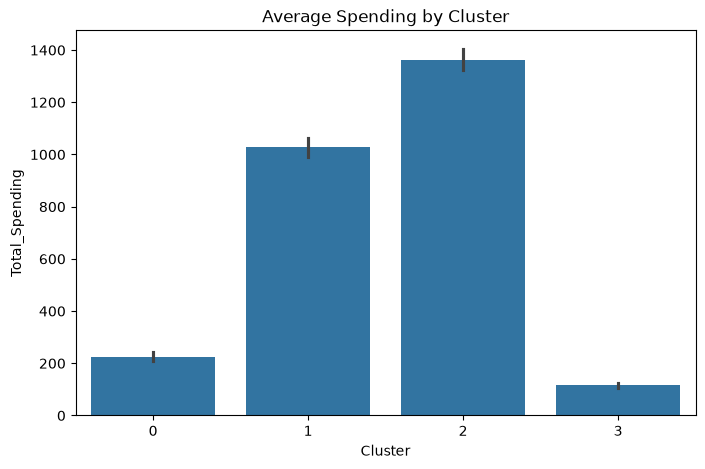

In [69]:
#Cluster-wise Spending
plt.figure(figsize=(8,5))

sns.barplot(
    x='Cluster',
    y='Total_Spending',
    data=df,
    estimator='mean')

plt.title("Average Spending by Cluster")

plt.show()

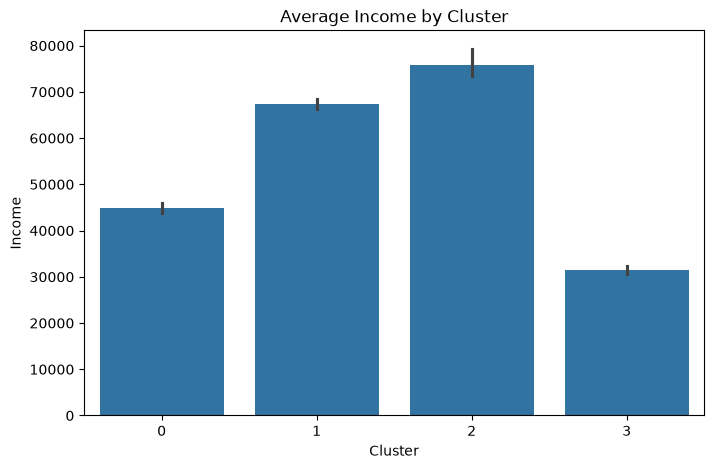

In [70]:
#Cluster-wise Income
plt.figure(figsize=(8,5))

sns.barplot(
    x='Cluster',
    y='Income',
    data=df,
    estimator='mean')

plt.title("Average Income by Cluster")

plt.show()

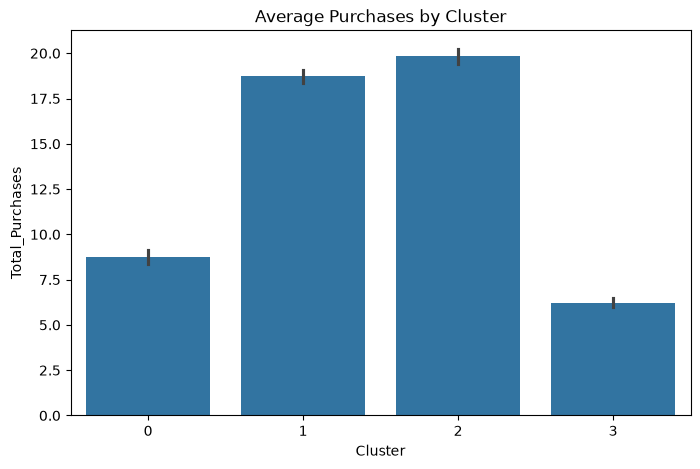

In [71]:
#Cluster-wise Purchases
plt.figure(figsize=(8,5))

sns.barplot(
    x='Cluster',
    y='Total_Purchases',
    data=df,
    estimator='mean')

plt.title("Average Purchases by Cluster")

plt.show()

In [101]:
cluster_summary

,Income,Age,Total_Spending,Total_Purchases,Family_Size
Cluster,,,,,
0,44951.0,62.0,225.0,9.0,3.564912
1,67341.0,69.0,1028.0,19.0,2.237319
2,75755.0,49.0,1364.0,20.0,1.945107
3,31474.0,49.0,116.0,6.0,2.466667


In [95]:
cluster_campaign

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Cluster,,,,,,
0,0.01,0.00,0.05,0.05,0.00,0.08
1,0.11,0.02,0.07,0.13,0.11,0.18
2,0.18,0.04,0.10,0.15,0.25,0.27
3,0.00,0.00,0.09,0.00,0.00,0.12


Cluster 2 is Premium High-Value Customer segment and contributes the greatest business value.

Cluster 1 consists of Affluent Loyal Customers who should be retained through exclusive benefits.

Cluster 0 contains Older Low-Value Customers who require engagement strategies to increase activity.

Cluster 3 represents Budget Customers who are highly price-sensitive and respond best to discounts.

**Export Data from Python**

In [ ]:
#After creating the clusters, save the final dataset
df.to_csv(r"customer_segmentation_final.csv", index=False)
print('Download Successfull....')

Download Successfull....
